In [42]:
#uses Jacobi iteration, guass seidel method, sor method to solve poisson eq
import numpy as np
import matplotlib.pyplot as plt
from copy import deepcopy
from mpl_toolkits.mplot3d import Axes3D


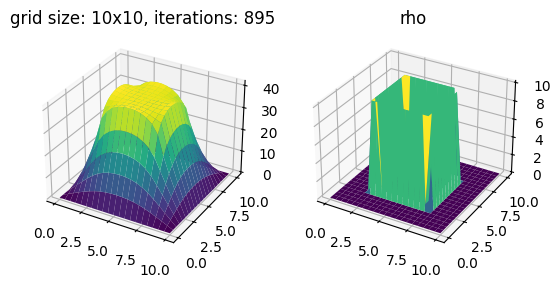

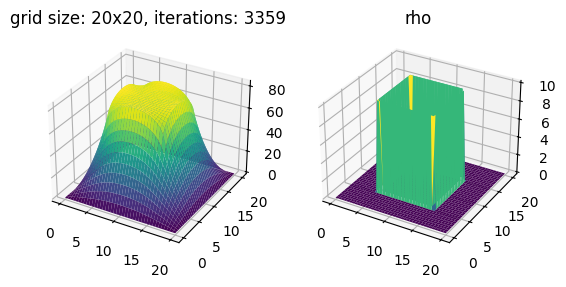

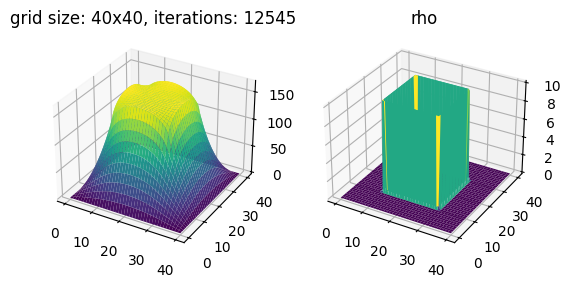

In [43]:
def jacobi(V,rho):
    V1=deepcopy(V)
    rho=deepcopy(rho)
    row,col=V.shape
    for i in range(1,row-1):
        for j in range(1,col-1):
            V1[i,j]=rho[i,j]/4+0.25*(V[i+1,j]+V[i-1,j]+V[i,j+1]+V[i,j-1])
    return V1

N=[10,20,40]
for i in N:
    V=np.zeros([2*i+1,2*i+1])
    rho=np.zeros(V.shape)
    rho[(int(0.5*i),int(1.5*i)),int(0.5*i):int(1.5*i)]=10*np.ones([2,i])
    rho[int(0.5*i):int(1.5*i),(int(0.5*i),int(1.5*i))]=10*np.ones([2,i]).T
    it=0
    while True:
        V1=jacobi(V,rho)
        it+=1
        if np.max(np.abs(V1-V))<1e-5:
            break
        V=V1
    
    x=np.linspace(0,i,2*i+1)
    y=np.linspace(0,i,2*i+1)
    X,Y=np.meshgrid(x,y)
    fig=plt.figure()
    ax=fig.add_subplot(121,projection='3d')
    ax.plot_surface(X,Y,V,cmap='viridis')
    ax.set_title(f'grid size: {i}x{i}, iterations: {it}')
    ax1=fig.add_subplot(122,projection='3d')
    ax1.plot_surface(X,Y,rho,cmap='viridis')
    ax1.set_title('rho')
    plt.show()

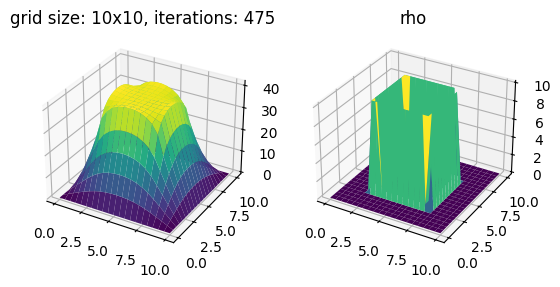

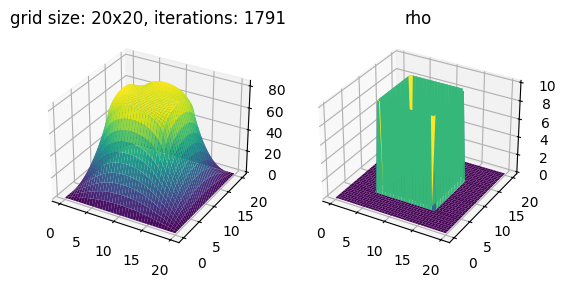

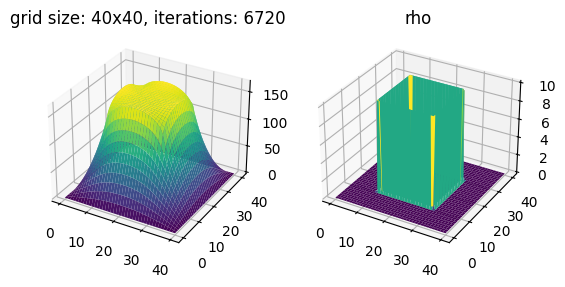

In [44]:
def Guass_Seidel(V,rho):
    V1=deepcopy(V)
    rho=deepcopy(rho)
    row,col=V.shape
    for i in range(1,row-1):
        for j in range(1,col-1):
            V1[i,j]=rho[i,j]/4+0.25*(V1[i+1,j]+V1[i-1,j]+V1[i,j+1]+V1[i,j-1])
    return V1

for i in N:
    V=np.zeros([2*i+1,2*i+1])
    rho=np.zeros(V.shape)
    rho[(int(0.5*i),int(1.5*i)),int(0.5*i):int(1.5*i)]=10*np.ones([2,i])
    rho[int(0.5*i):int(1.5*i),(int(0.5*i),int(1.5*i))]=10*np.ones([2,i]).T
    it=0
    while True:
        V1=Guass_Seidel(V,rho)
        it+=1
        if np.max(np.abs(V1-V))<1e-5:
            break
        V=V1
    
    x=np.linspace(0,i,2*i+1)
    y=np.linspace(0,i,2*i+1)
    X,Y=np.meshgrid(x,y)
    fig=plt.figure()
    ax=fig.add_subplot(121,projection='3d')
    ax.plot_surface(X,Y,V,cmap='viridis')
    ax.set_title(f'grid size: {i}x{i}, iterations: {it}')
    ax1=fig.add_subplot(122,projection='3d')
    ax1.plot_surface(X,Y,rho,cmap='viridis')
    ax1.set_title('rho')
    plt.show()

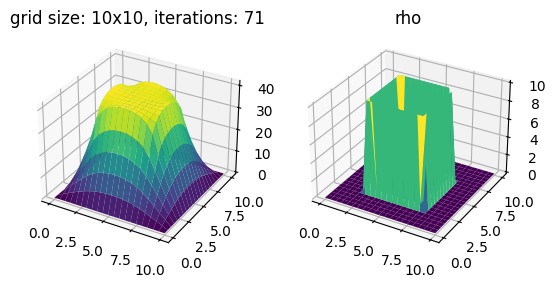

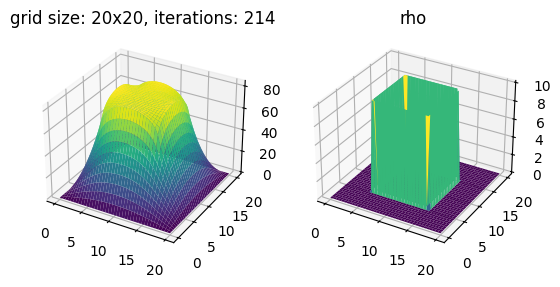

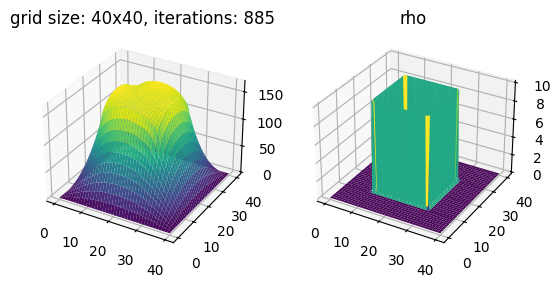

In [45]:
def sor(V,rho,omega):
    V1=deepcopy(V)
    rho=deepcopy(rho)
    row,col=V.shape
    for i in range(1,row-1):
        for j in range(1,col-1):
            V1[i,j]=(1-omega)*V[i,j]+omega*(rho[i,j]/4+0.25*(V1[i+1,j]+V1[i-1,j]+V1[i,j+1]+V1[i,j-1]))
    return V1

for i in N:
    V=np.zeros([2*i+1,2*i+1])
    rho=np.zeros(V.shape)
    rho[(int(0.5*i),int(1.5*i)),int(0.5*i):int(1.5*i)]=10*np.ones([2,i])
    rho[int(0.5*i):int(1.5*i),(int(0.5*i),int(1.5*i))]=10*np.ones([2,i]).T
    it=0
    omega=1.8
    while True:
        V1=sor(V,rho,omega)
        it+=1
        if np.max(np.abs(V1-V))<1e-5:
            break
        V=V1
    
    x=np.linspace(0,i,2*i+1)
    y=np.linspace(0,i,2*i+1)
    X,Y=np.meshgrid(x,y)
    fig=plt.figure()
    ax=fig.add_subplot(121,projection='3d')
    ax.plot_surface(X,Y,V,cmap='viridis')
    ax.set_title(f'grid size: {i}x{i}, iterations: {it}')
    ax1=fig.add_subplot(122,projection='3d')
    ax1.plot_surface(X,Y,rho,cmap='viridis')
    ax1.set_title('rho')
    plt.show()

In [46]:
#change the rho into the Star of David

In [47]:
def triangle(rho,i,j):
    rho=deepcopy(rho)
    for m in range(0,2*i-1):
        for n in range(0,2*j-1):
            if 0.8*i<=m<=1.6*i and -3*m+5*n>=0.2*i and 3*m+5*n<=9.8*i:
                rho[m,n]=10
    return rho

def invtriangle(rho,i,j):
    rho=deepcopy(rho)
    for m in range(0,2*i-1):
        for n in range(0,2*j-1):
            if 0.2*i<=m<=1.2*i and -3*m+5*n<=3.8*i and 3*m+5*n>=6.2*i:
                rho[m,n]=10
    return rho

def stardavid(rho,i,j):
    rho=deepcopy(rho)
    rho=triangle(rho,i,j)
    rho=invtriangle(rho,i,j)
    return rho

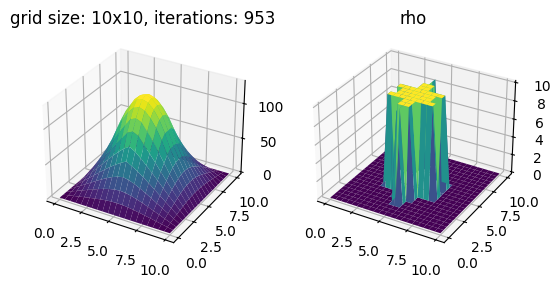

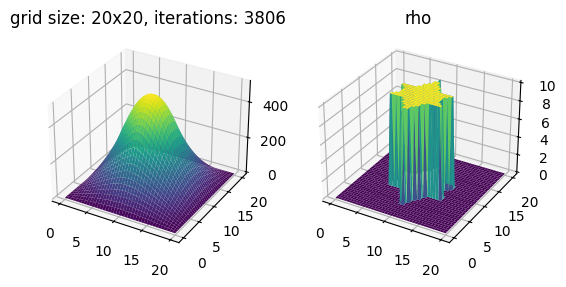

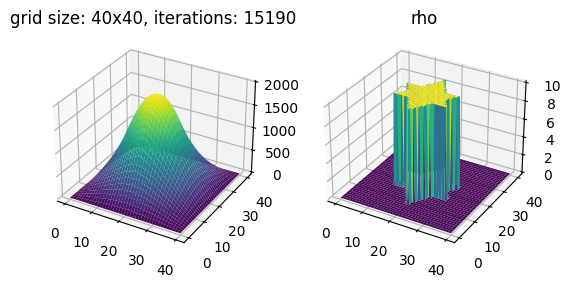

In [48]:
N=[10,20,40]
for i in N:
    V=np.zeros([2*i+1,2*i+1])
    rho=np.zeros(V.shape)
    rho=stardavid(rho,i,i)
    it=0
    while True:
        V1=jacobi(V,rho)
        it+=1
        if np.max(np.abs(V1-V))<1e-5:
            break
        V=V1
    
    x=np.linspace(0,i,2*i+1)
    y=np.linspace(0,i,2*i+1)
    X,Y=np.meshgrid(x,y)
    fig=plt.figure()
    ax=fig.add_subplot(121,projection='3d')
    ax.plot_surface(X,Y,V,cmap='viridis')
    ax.set_title(f'grid size: {i}x{i}, iterations: {it}')
    ax1=fig.add_subplot(122,projection='3d')
    ax1.plot_surface(X,Y,rho,cmap='viridis')
    ax1.set_title('rho')
    plt.show()

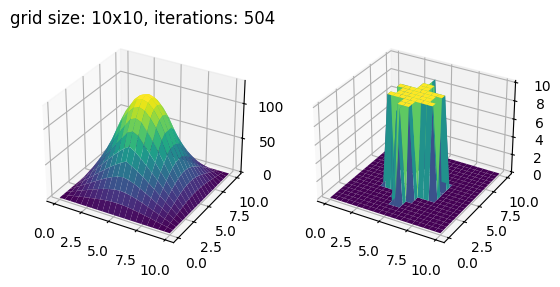

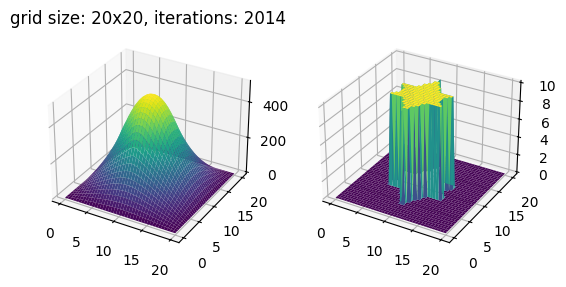

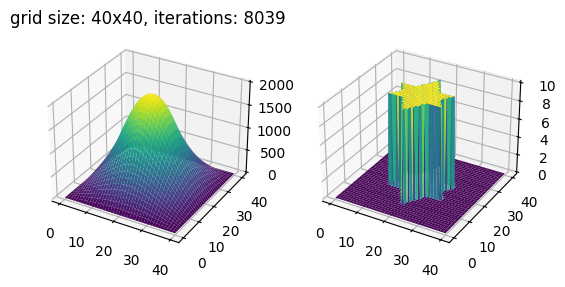

In [49]:
for i in N:     
    V=np.zeros([2*i+1,2*i+1])
    rho=np.zeros(V.shape)
    rho=stardavid(rho,i,i)
    it=0
    while True:
        V1=Guass_Seidel(V,rho)
        it+=1
        if np.max(np.abs(V1-V))<1e-5:
            break
        V=V1
    
    x=np.linspace(0,i,2*i+1)
    y=np.linspace(0,i,2*i+1)
    X,Y=np.meshgrid(x,y)
    fig=plt.figure()
    ax=fig.add_subplot(121,projection='3d')
    ax.plot_surface(X,Y,V,cmap='viridis')
    ax.set_title(f'grid size: {i}x{i}, iterations: {it}')
    ax1=fig.add_subplot(122,projection='3d')
    ax1.plot_surface(X,Y,rho,cmap='viridis')
    plt.show()

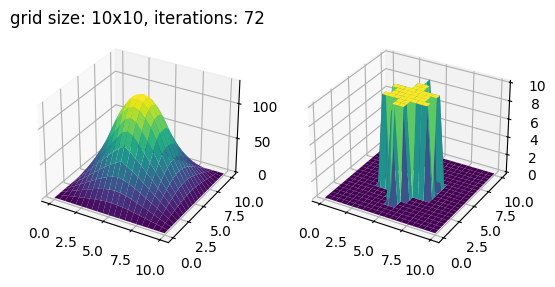

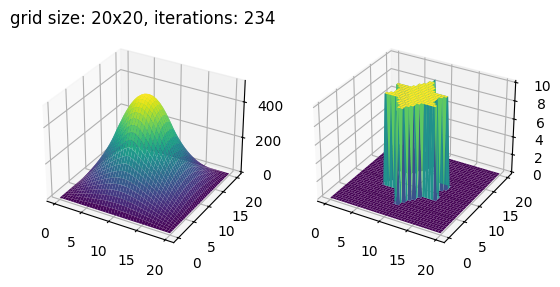

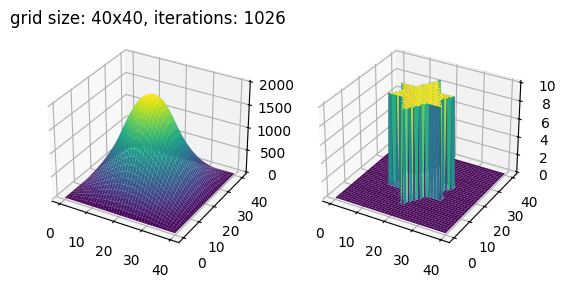

In [50]:
for i in N:     
    V=np.zeros([2*i+1,2*i+1])
    rho=np.zeros(V.shape)
    rho=stardavid(rho,i,i)
    it=0
    omega=1.8
    while True:
        V1=sor(V,rho,omega)
        it+=1
        if np.max(np.abs(V1-V))<1e-5:
            break
        V=V1
    
    x=np.linspace(0,i,2*i+1)
    y=np.linspace(0,i,2*i+1)
    X,Y=np.meshgrid(x,y)
    fig=plt.figure()
    ax=fig.add_subplot(121,projection='3d')
    ax.plot_surface(X,Y,V,cmap='viridis')
    ax.set_title(f'grid size: {i}x{i}, iterations: {it}')
    ax1=fig.add_subplot(122,projection='3d')
    ax1.plot_surface(X,Y,rho,cmap='viridis')
    plt.show()